# AstroCLIMB - Kimi-VL-A3B-Thinking (Phase 2, Few-Shot Prompting)

**Model:** `moonshotai/Kimi-VL-A3B-Thinking` (3B MoE, ~8GB bfloat16, native `<think>` reasoning)

**Dataset:** OLD 7-column CSV (`train.csv`), 1800 balanced (450/label), base64 images

**Hardware:** Kaggle 2x T4 (15.6GB each), `device_map="auto"`, bfloat16

**NO HF_TOKEN required** (Apache 2.0, public)

**Classes (submission order):** `same_figure, same_paper, related_papers, unrelated_papers`

In [1]:
# --- 1. Setup ---
import os, json, time, re, gc, base64, sys, subprocess
from pathlib import Path
from io import BytesIO
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch

print(f"torch {torch.__version__} cuda {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    raise SystemExit("STOP - Enable GPU T4 x2")
assert torch.cuda.device_count() >= 2, "REQUIRE 2x T4"

# Install from source BEFORE importing - kimi_vl requires custom_code support
print("Installing transformers from source for kimi-vl support...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/huggingface/transformers.git", "accelerate"])
for m in list(sys.modules.keys()):
    if m.startswith("transformers"):
        del sys.modules[m]
import importlib as _il; _il.invalidate_caches()

import transformers
print(f"transformers {transformers.__version__}")

# Monkey-patch: is_torch_fx_available was removed in transformers 5.x
import transformers.utils.import_utils as _iu
if not hasattr(_iu, 'is_torch_fx_available'):
    _iu.is_torch_fx_available = lambda: False
    print("Patched is_torch_fx_available")

print("Kimi-VL-A3B: bfloat16, no bitsandbytes needed")

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
print("PYTORCH_ALLOC_CONF set")

torch 2.10.0+cu128 cuda True
['Tesla T4', 'Tesla T4']
VRAM: 15.6 GB
Installing transformers from source for kimi-vl support...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 53.3 MB/s eta 0:00:00
transformers 5.17.0.dev0
Patched is_torch_fx_available
Kimi-VL-A3B: bfloat16, no bitsandbytes needed
PYTORCH_ALLOC_CONF set


In [2]:
# --- 2. Data loading (DUAL dataset) ---
NEW_CSV = "/kaggle/input/datasets/jcxiv42/astroclimb/astroclimb_4class(sampled).csv"
NEW_IMG_DIR = "/kaggle/input/datasets/jcxiv42/astroclimb/object_images_sampled/object_images_sampled"
OLD_CSV = "/kaggle/input/competitions/astroclimb/train.csv"

new_df = pd.read_csv(NEW_CSV)
print(f"NEW dataset (few-shot source): {new_df.shape}")
print(new_df["label_name"].value_counts())

train = pd.read_csv(OLD_CSV)
print(f"\nOLD dataset (evaluation): {train.shape}")
print(train.columns.tolist())
display(train.head(2))

label_cols = ["same_figure", "same_paper", "related_papers", "unrelated_papers"]
train["label"] = train[label_cols].idxmax(axis=1)
train["label_id"] = train["label"].map({c: i for i, c in enumerate(label_cols)})
print(train["label"].value_counts())
print(train[label_cols].sum())

NEW dataset (few-shot source): (1800, 23)
label_name
same figure         450
related papers      450
same paper          450
unrelated papers    450
Name: count, dtype: int64

OLD dataset (evaluation): (10000, 7)
['id', 'same_figure', 'same_paper', 'related_papers', 'unrelated_papers', 'obj_1', 'obj_2']


,id,same_figure,same_paper,related_papers,unrelated_papers,obj_1,obj_2
0,0,1,0,0,0,Distribution of the RVs for TOI-2046b in the t...,iVBORw0KGgoAAAANSUhEUgAACVYAAAZUCAIAAACPYVwUAA...
1,1,1,0,0,0,Vertical structures of the Martian background ...,iVBORw0KGgoAAAANSUhEUgAABwgAAAQ2CAIAAACoaX6RAA...


label
same_paper          3000
related_papers      3000
unrelated_papers    3000
same_figure         1000
Name: count, dtype: int64
same_figure         1000
same_paper          3000
related_papers      3000
unrelated_papers    3000
dtype: int64


In [3]:
# --- 3. Helpers ---
def is_image_str(s):
    if not isinstance(s, str) or len(s) < 200:
        return False
    return s.strip().startswith("iVBORw0KGgo")

def convert_str_to_PIL(img_str):
    return Image.open(BytesIO(base64.b64decode(img_str))).convert("RGB")

def load_image_from_uuid(uuid, img_dir=NEW_IMG_DIR):
    img_path = Path(img_dir) / f"{uuid}.png"
    if img_path.exists():
        return Image.open(img_path).convert("RGB")
    return None

train["obj_1_is_img"] = train["obj_1"].apply(is_image_str)
train["obj_2_is_img"] = train["obj_2"].apply(is_image_str)
train["pair_type"] = train.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
print("OLD pair types:", train["pair_type"].value_counts().to_dict())

def get_new_pair_type(t1, t2):
    if t1 == "figure" and t2 == "caption": return "FIG-CAP"
    if t1 == "caption" and t2 == "figure": return "CAP-FIG"
    if t1 == "figure" and t2 == "figure": return "FIG-FIG"
    if t1 == "caption" and t2 == "caption": return "CAP-CAP"
    return "UNKNOWN"

new_df["pair_type"] = new_df.apply(lambda r: get_new_pair_type(r["object_1_type"], r["object_2_type"]), axis=1)
print("NEW pair types:", new_df["pair_type"].value_counts().to_dict())

OLD pair types: {'TXT-IMG': 4000, 'IMG-IMG': 3000, 'TXT-TXT': 3000}
NEW pair types: {'FIG-CAP': 450, 'CAP-FIG': 450, 'CAP-CAP': 450, 'FIG-FIG': 450}


In [4]:
# --- 3b. Balanced sampler (1800 = 450/class) ---
def sample_balanced(df, n_per_class=450, seed=42):
    import pandas as pd
    assert n_per_class % 3 == 0, "n_per_class must be divisible by 3"
    parts = []
    for label in ["same_figure", "same_paper", "related_papers", "unrelated_papers"]:
        sub = df[df["label"] == label]
        if label == "same_figure":
            parts.append(sub[sub["pair_type"] == "TXT-IMG"].sample(n=n_per_class, random_state=seed))
        else:
            per_pair = n_per_class // 3
            for pt in ["TXT-IMG", "IMG-IMG", "TXT-TXT"]:
                g = sub[sub["pair_type"] == pt]
                if len(g) < per_pair:
                    print(f"Warning: {label} {pt} has {len(g)} < {per_pair}, taking all")
                    parts.append(g)
                else:
                    parts.append(g.sample(n=per_pair, random_state=seed))
    bal = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return bal

train_bal = sample_balanced(train, n_per_class=450, seed=42)
print(f"train_bal {train_bal.shape} (target 1800 = 450*4)")
print(train_bal["label"].value_counts())
print(pd.crosstab(train_bal["label"], train_bal["pair_type"]))
print(f"Estimated time: {len(train_bal)*12.5/3600:.1f}h at 12.5s/it")

train_bal (1800, 12) (target 1800 = 450*4)
label
unrelated_papers    450
related_papers      450
same_paper          450
same_figure         450
Name: count, dtype: int64
pair_type         IMG-IMG  TXT-IMG  TXT-TXT
label                                      
related_papers        150      150      150
same_figure             0      450        0
same_paper            150      150      150
unrelated_papers      150      150      150
Estimated time: 6.2h at 12.5s/it


In [5]:
# --- 4. System Prompt + Few-Shot Examples from NEW Dataset ---
SYSTEM_PROMPT = """You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.
- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.
- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.
- unrelated_papers: No clear link. Different topics, instruments, scales, or writing/visual style with no overlap.

Base your decision only on visual and textual content. Do not assume same_figure is impossible for any pair type - judge from alignment.
Output ONLY the lowercase label (e.g., related_papers), no explanation, no punctuation."""

# Sample few-shot examples from NEW dataset (1 per class)
FEW_SHOT_EXAMPLES = []
FEW_SHOT_PER_CLASS = 1  # 1 example per class = 4 total few-shot examples
few_shot_seed = 42
for label in ["same_figure", "same_paper", "related_papers", "unrelated_papers"]:
    label_with_space = label.replace("_", " ")
    # robust: strip whitespace in label_name
    subset = new_df[new_df["label_name"].astype(str).str.strip() == label_with_space]
    if len(subset) == 0:
        print(f"Warning: no rows for {label} ({label_with_space}) in NEW dataset, skipping")
        continue
    n_cand = min(FEW_SHOT_PER_CLASS * 3, len(subset))
    if n_cand == 0:
        print(f"Warning: n_cand 0 for {label}, skipping")
        continue
    candidates = subset.sample(n=n_cand, random_state=few_shot_seed)
    # Prefer FIG-CAP pairs (figure + caption) for clearer examples
    fig_cap = candidates[candidates["pair_type"].isin(["FIG-CAP", "CAP-FIG"])]
    if len(fig_cap) >= FEW_SHOT_PER_CLASS:
        examples = fig_cap.sample(n=FEW_SHOT_PER_CLASS, random_state=few_shot_seed)
    elif len(candidates) >= FEW_SHOT_PER_CLASS:
        examples = candidates.sample(n=FEW_SHOT_PER_CLASS, random_state=few_shot_seed)
    else:
        print(f"Warning: not enough candidates for {label}, skipping")
        continue
    for _, ex_row in examples.iterrows():
        # Load images from UUID
        img1 = load_image_from_uuid(ex_row["object_1_uuid"])
        img2 = load_image_from_uuid(ex_row["object_2_uuid"])
        FEW_SHOT_EXAMPLES.append({
            "label": label,
            "obj_1": str(ex_row["object_1_content"])[:2000] if ex_row["object_1_type"] == "caption" else img1,
            "obj_2": str(ex_row["object_2_content"])[:2000] if ex_row["object_2_type"] == "caption" else img2,
            "obj_1_is_img": ex_row["object_1_type"] == "figure",
            "obj_2_is_img": ex_row["object_2_type"] == "figure"
        })

print(f"Sampled {len(FEW_SHOT_EXAMPLES)} few-shot examples from NEW dataset:")
for ex in FEW_SHOT_EXAMPLES:
    print(f"  {ex['label']}: obj1_img={ex['obj_1_is_img']}, obj2_img={ex['obj_2_is_img']}")

print("\nSystem prompt:")
print(SYSTEM_PROMPT[:400])

# --- FEW-SHOT VERIFICATION (visible in logs) ---
print(f"\n{'='*60}")
print(f"FEW-SHOT IN PROMPT: {len(FEW_SHOT_EXAMPLES)} examples (1 per class) from NEW dataset")
for ex in FEW_SHOT_EXAMPLES:
    if ex['obj_1_is_img']:
        t1 = f"[FIG {ex['obj_1'].size if hasattr(ex['obj_1'],'size') else 'PIL'}]"
    else:
        t1 = str(ex['obj_1'])[:120].replace(chr(10),' ')
    if ex['obj_2_is_img']:
        t2 = f"[FIG {ex['obj_2'].size if hasattr(ex['obj_2'],'size') else 'PIL'}]"
    else:
        t2 = str(ex['obj_2'])[:120].replace(chr(10),' ')
    print(f"  [{ex['label']:16}] A: {t1[:80]} | B: {t2[:80]}")
print(f"{'='*60}")
print(f"EVALUATION DATASET: OLD train.csv balanced 1800 (450 per class) -> train_bal")
print(f"FEW-SHOT SOURCE  : NEW dataset (23-col, UUID images) -> 4 examples injected as user/assistant turns")


Sampled 4 few-shot examples from NEW dataset:
  same_figure: obj1_img=True, obj2_img=False
  same_paper: obj1_img=False, obj2_img=False
  related_papers: obj1_img=False, obj2_img=False
  unrelated_papers: obj1_img=True, obj2_img=False

System prompt:
You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned ve

FEW-SHOT IN PROMPT: 4 examples (1 per class) from NEW dataset
  [same_figure     ] A: [FIG (1817, 1293)] | B: Polarization profiles of FRB 20201124A burst #1. The PA swing and the profile of
  [same_paper      ] A: Polarized intensity around the HH 211 envelope in Band 3 with a robust parameter | B: Spectral index components between 97.5 and 233

In [6]:
# --- 5. Model loading (Kimi-VL-A3B-Thinking, bfloat16, 2xT4) ---
from transformers import AutoProcessor, AutoModelForCausalLM

MODEL_ID = "moonshotai/Kimi-VL-A3B-Thinking"
ENABLE_THINKING = True
BATCH_SIZE = 1
MAX_NEW_TOKENS = 512

device = "cuda"
print(f"Loading {MODEL_ID}")
print(f"Thinking={ENABLE_THINKING} batch={BATCH_SIZE} max_tokens={MAX_NEW_TOKENS}")

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print(f"Processor loaded: {type(processor).__name__}")

# 3B params, loads in bfloat16 (~8GB) - no quantization needed
# attn_implementation='eager' needed: KimiVLForConditionalGeneration lacks _supports_sdpa
# Fix rope_scaling incompatibility (transformers 5.x compat)
from transformers import AutoConfig
config = AutoConfig.from_pretrained(MODEL_ID, trust_remote_code=True)
if hasattr(config, 'text_config') and hasattr(config.text_config, 'rope_scaling'):
    if config.text_config.rope_scaling is not None:
        print(f"Clearing rope_scaling: {config.text_config.rope_scaling}")
        config.text_config.rope_scaling = None

# Patch tie_weights for transformers 5.x compat (Kimi expects no recompute_mapping arg)
import transformers.modeling_utils
_orig_init = transformers.modeling_utils.PreTrainedModel.init_weights
def _patched_init_weights(self):
    try:
        if hasattr(self, "initialize_weights"):
            try:
                self.initialize_weights()
            except Exception:
                pass
        try:
            self.tie_weights(recompute_mapping=False)
        except TypeError as e:
            if "recompute_mapping" in str(e):
                self.tie_weights()
            else:
                raise
        self._backward_compatibility_gradient_checkpointing()
    except Exception as e:
        if "recompute_mapping" not in str(e):
            raise
        try:
            self.tie_weights()
        except Exception:
            pass
transformers.modeling_utils.PreTrainedModel.init_weights = _patched_init_weights
print("Patched init_weights for Kimi tie_weights compat")

# Patch DynamicCache for transformers 5.16 compat (get_usable_length, seen_tokens)
try:
    from transformers.cache_utils import DynamicCache
    if not hasattr(DynamicCache, "get_usable_length"):
        def _get_usable_length(self, seq_length=None, *args, **kwargs):
            try: return self.get_seq_length()
            except: return 0
        DynamicCache.get_usable_length = _get_usable_length
        print("Patched DynamicCache.get_usable_length")
    if not hasattr(DynamicCache, "seen_tokens"):
        DynamicCache.seen_tokens = property(lambda self: self.get_seq_length())
        print("Patched DynamicCache.seen_tokens")
except Exception as _e:
    print(f"DynamicCache patch failed {_e}")

# Robust patch: ensure cached modeling file handles 5.16 API changes
import pathlib as _pl, re as _re
try:
    from huggingface_hub import hf_hub_download
    _dl = hf_hub_download(repo_id=MODEL_ID, filename="modeling_kimi_vl.py")
    print(f"Ensured modeling file cached: {_dl}")
except Exception as _e:
    print(f"hf_hub_download modeling file failed: {_e}")
for _p in list(_pl.Path.home().glob(".cache/huggingface/modules/transformers_modules/moonshotai/Kimi*/*/modeling_kimi_vl.py")) + list(_pl.Path.home().glob(".cache/huggingface/hub/models--moonshotai--Kimi*/*/*/modeling_kimi_vl.py")) + list(_pl.Path.home().glob(".cache/huggingface/hub/models--moonshotai--Kimi*/snapshots/*/modeling_kimi_vl.py")):
    try:
        _txt = _p.read_text()
        _orig = _txt
        if "def tie_weights(self):" in _txt:
            _txt = _txt.replace("def tie_weights(self):", "def tie_weights(self, *args, **kwargs):")
        if "def tie_weights" in _txt and "*args" not in _txt.split("def tie_weights")[1].split(")")[0]:
            _txt = _re.sub(r"def tie_weights\(self,([^\)]*)\):", r"def tie_weights(self, \1, *args, **kwargs):", _txt)
            _txt = _txt.replace(", ,", ",").replace("( ,", "(").replace(" , *args", ", *args")
        if "past_key_values.seen_tokens" in _txt:
            _txt = _txt.replace("past_key_values.seen_tokens", "past_key_values.get_seq_length()")
            _txt = _txt.replace("past_key_values.get_seq_length().get_seq_length()", "past_key_values.get_seq_length()")
        if "cache_position[0] == 0" in _txt:
            _txt = _txt.replace("if cache_position[0] == 0:", "if cache_position is None or cache_position[0] == 0:")
        if "get_usable_length" in _txt:
            _txt = _re.sub(r"past_key_value\.get_usable_length\(kv_seq_len, self\.layer_idx\)", "past_key_value.get_seq_length(self.layer_idx)", _txt)
            _txt = _re.sub(r"past_key_values\.get_usable_length\([^)]*\)", "past_key_values.get_seq_length()", _txt)
            _txt = _txt.replace("past_key_values.get_usable_length", "past_key_values.get_seq_length")
            _txt = _txt.replace("past_key_value.get_usable_length", "past_key_value.get_seq_length")
        if _txt != _orig:
            _p.write_text(_txt)
            print(f"Patched file {_p}")
    except Exception as _e2:
        print(f"Patch file {_p} failed {_e2}")

# Try loading with retry for tie_weights compat
import time as _t
model = None
for _attempt in range(3):
    try:
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, device_map="auto", config=config,
            dtype=torch.bfloat16, attn_implementation="eager", trust_remote_code=True
        )
        print(f"Model loaded: {type(model).__name__}, has generate: {hasattr(model, 'generate')}")
        break
    except TypeError as _e:
        if "tie_weights" in str(_e) and ("missing_keys" in str(_e) or "recompute_mapping" in str(_e)):
            print(f"tie_weights compat error attempt {_attempt}: {_e}, patching and retry")
            try:
                import transformers.modeling_utils as _mu
                _orig_tie = _mu.PreTrainedModel.tie_weights
                def _tolerant_tie(self, *args, **kwargs):
                    try:
                        return _orig_tie(self, *args, **kwargs)
                    except TypeError:
                        return _orig_tie(self)
                _mu.PreTrainedModel.tie_weights = _tolerant_tie
            except: pass
            try:
                import transformers.modeling_utils as _mu2
                _orig_final = _mu2.PreTrainedModel._finalize_model_loading
                @classmethod
                def _patched_final(cls, model, load_config, loading_info):
                    try:
                        return _orig_final(model, load_config, loading_info)
                    except TypeError as _e2:
                        if "tie_weights" in str(_e2):
                            try: model.tie_weights()
                            except: pass
                            loading_info.missing_keys = []
                            return loading_info
                        raise
                _mu2.PreTrainedModel._finalize_model_loading = _patched_final
            except: pass
            _t.sleep(1)
            continue
        else:
            raise
if model is None:
    raise RuntimeError("Kimi loading failed after retries")
model.eval()
print(f"Model loaded: {type(model).__name__}, has generate: {hasattr(model, 'generate')}")


Loading moonshotai/Kimi-VL-A3B-Thinking
Thinking=True batch=1 max_tokens=512


preprocessor_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_kimi_vl.py: 0.00B [00:00, ?B/s]

...

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/5652 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/149 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded: KimiVLForConditionalGeneration, has generate: True
Model loaded: KimiVLForConditionalGeneration, has generate: True


In [7]:
# --- 6. Messages builder ---
def build_user_content(row):
    parts = []
    for col, name in [("obj_1", "Object A"), ("obj_2", "Object B")]:
        s = row[col]
        if row[f"{col}_is_img"]:
            parts.append({"name": name, "is_img": True, "pil": convert_str_to_PIL(s)})
        else:
            txt = str(s)[:2000]
            parts.append({"name": name, "is_img": False, "text": txt})
    return parts

def build_few_shot_messages(examples):
    """Build few-shot example messages (handles PIL images from NEW dataset)"""
    messages = []
    for ex in examples:
        user_content = [{"type": "text", "text": "Classify this pair:\n"}]
        if ex["obj_1_is_img"]:
            im = ex["obj_1"]  # Already PIL from load_image_from_uuid
            if im is not None:
                im = im.copy()
                im.thumbnail((448, 448))
                user_content.append({"type": "image", "image": im})
            user_content.append({"type": "text", "text": "\nObject A: [Figure image]"})
        else:
            user_content.append({"type": "text", "text": "\nObject A (caption): " + str(ex["obj_1"])[:1000]})
        if ex["obj_2_is_img"]:
            im = ex["obj_2"]  # Already PIL from load_image_from_uuid
            if im is not None:
                im = im.copy()
                im.thumbnail((448, 448))
                user_content.append({"type": "image", "image": im})
            user_content.append({"type": "text", "text": "\nObject B: [Figure image]"})
        else:
            user_content.append({"type": "text", "text": "\nObject B (caption): " + str(ex["obj_2"])[:1000]})
        user_content.append({"type": "text", "text": "\nAnswer with one label:"})
        messages.append({"role": "user", "content": user_content})
        messages.append({"role": "assistant", "content": [{"type": "text", "text": ex["label"]}]})
    return messages

def build_messages_kimi(row):
    messages = []
    messages.append({"role": "user", "content": [{"type": "text", "text": SYSTEM_PROMPT}]})
    messages.append({"role": "assistant", "content": [{"type": "text", "text": "Understood. I will classify pairs based on visual and textual content."}]})
    few_shot_msgs = build_few_shot_messages(FEW_SHOT_EXAMPLES)
    messages.extend(few_shot_msgs)
    
    test_content = [{"type": "text", "text": "Classify this pair:\n"}]
    parts = build_user_content(row)
    for p in parts:
        if p["is_img"]:
            im = p["pil"].copy()
            im.thumbnail((448, 448))
            test_content.append({"type": "image", "image": im})
            test_content.append({"type": "text", "text": "\n" + p["name"] + ": [Figure image]"})
        else:
            test_content.append({"type": "text", "text": "\n" + p["name"] + " (caption): " + p["text"]})
    test_content.append({"type": "text", "text": "\nAnswer with one label:"})
    messages.append({"role": "user", "content": test_content})
    return messages

print("Message builder OK (with few-shot examples)")

# --- FEW-SHOT MESSAGE VERIFICATION ---
_debug_msgs = build_messages_kimi(train_bal.iloc[0])
print(f"FEW-SHOT MESSAGE VERIFICATION: total messages={len(_debug_msgs)} (expect 2 sys+ack + 8 few-shot (4 pairs) +1 test =11)")
for idx in range(2, min(10, len(_debug_msgs))):
    role = _debug_msgs[idx]['role']
    txt = _debug_msgs[idx]['content'][0]['text'][:60] if _debug_msgs[idx]['content'][0].get('type') == 'text' else '[image]'
    print(f"  msg[{idx}] {role}: {txt}")
del _debug_msgs

Message builder OK (with few-shot examples)
FEW-SHOT MESSAGE VERIFICATION: total messages=11 (expect 2 sys+ack + 8 few-shot (4 pairs) +1 test =11)
  msg[2] user: Classify this pair:

  msg[3] assistant: same_figure
  msg[4] user: Classify this pair:

  msg[5] assistant: same_paper
  msg[6] user: Classify this pair:

  msg[7] assistant: related_papers
  msg[8] user: Classify this pair:

  msg[9] assistant: unrelated_papers


In [8]:
# --- 7. Inference ---
label_pattern = re.compile(r"(same_figure|same_paper|related_papers|unrelated_papers)", re.IGNORECASE)

def parse_label(text):
    m = label_pattern.search(text.lower())
    return m.group(1).lower() if m else "unrelated_papers"

raw_outputs = []
start_time = time.time()

def predict_kimi(df, batch_size=BATCH_SIZE, save_every=1000, save_path="preds_train.npy", raw_path="raw_outputs.jsonl"):
    preds = []
    for i in tqdm(range(0, len(df), batch_size), desc="Infer"):
        batch = df.iloc[i:i+batch_size]
        for j, (_, row) in enumerate(batch.iterrows()):
            try:
                messages = build_messages_kimi(row)
                text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
                # Debug: print first prompt to verify few-shot
                if i == 0 and j == 0:
                    print(f"DEBUG RENDERED PROMPT (first 2000 chars):\n{text[:2000]}")
                    print(f"DEBUG: few-shot labels in prompt: {[ex['label'] for ex in FEW_SHOT_EXAMPLES]}")
                images = []
                for turn in messages:
                    for part in turn["content"]:
                        if part.get("type") == "image" and "image" in part:
                            im = part["image"]
                            im.thumbnail((448, 448))
                            images.append(im)
                images = images if images else None
                inputs = processor(text=[text], images=images, padding=True, return_tensors="pt")
                inputs = inputs.to(model.device)
                input_len = inputs["input_ids"].shape[1]
                
                gen_kwargs = {"max_new_tokens": MAX_NEW_TOKENS, "do_sample": False, "use_cache": True}
                if ENABLE_THINKING:
                    gen_kwargs.update({"temperature": 0.6, "top_p": 0.95, "do_sample": True})
                with torch.no_grad():
                    out = model.generate(**inputs, **gen_kwargs)
                decoded = processor.batch_decode(out[:, input_len:], skip_special_tokens=True)[0]
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    print(f"OOM at {i+j}")
                    torch.cuda.empty_cache(); gc.collect()
                    decoded = "unrelated_papers"
                else:
                    raise
            
            thinking = ""
            if "<think>" in decoded:
                parts = decoded.split("</think>")
                if len(parts) > 1:
                    thinking = parts[0].split("<think>")[-1].strip()
                    decoded = parts[-1].strip()
            pred = parse_label(decoded)
            
            raw_outputs.append({
                "true_label": str(row.get("label", "")),
                "pred": pred,
                "thinking": thinking,
                "raw": decoded
            })
            preds.append(pred)
        
        if (i // batch_size + 1) % (save_every // batch_size) == 0:
            np.save(save_path, np.array(preds))
            with open(raw_path, "w", encoding="utf-8") as f:
                for r in raw_outputs:
                    f.write(json.dumps(r, ensure_ascii=False) + "\n")
            print(f"Checkpoint {len(preds)}/{len(df)} saved")
            torch.cuda.empty_cache(); gc.collect()
        if time.time() - start_time > 6.5 * 3600:
            print("6.5h reached")
            break
    return np.array(preds)

from tqdm import tqdm
print(f"Starting inference: {len(train_bal)} samples")

Starting inference: 1800 samples


In [9]:
# --- 8. Run ---
preds_train = predict_kimi(train_bal, batch_size=BATCH_SIZE, save_path="preds_train.npy")
print(f"Done {len(preds_train)} in {(time.time()-start_time)/3600:.2f}h")
np.save("preds_train_bal_final.npy", preds_train)
with open("raw_outputs_final.jsonl", "w", encoding="utf-8") as f:
    for r in raw_outputs:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
np.save("raw_outputs_final.npy", np.array(raw_outputs, dtype=object))
print(f"Raw saved: {len(raw_outputs)} samples")

Infer:   0%|          | 0/1800 [00:00<?, ?it/s]

DEBUG RENDERED PROMPT (first 2000 chars):
<|im_system|>system<|im_middle|>You are a helpful assistant<|im_end|><|im_user|>user<|im_middle|>You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.
- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.
- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but 

Infer:   0%|          | 1/1800 [00:01<55:45,  1.86s/it]/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be

OOM at 1


Infer:   0%|          | 3/1800 [00:52<11:25:17, 22.88s/it]

...

OOM at 1797


Infer: 100%|█████████▉| 1799/1800 [4:11:38<00:07,  7.93s/it]

OOM at 1798
OOM at 1799


Infer: 100%|██████████| 1800/1800 [4:11:47<00:00,  8.39s/it]

Done 1800 in 4.20h
Raw saved: 1800 samples


In [10]:
# --- 9. Metrics ---
y_true_all = train_bal["label"].values
y_pred_all = preds_train

if len(y_pred_all) != len(y_true_all):
    print(f"Warning: preds {len(y_pred_all)} != true {len(y_true_all)}")
    n = min(len(y_true_all), len(y_pred_all))
    y_true, y_pred = y_true_all[:n], y_pred_all[:n]
else:
    y_true, y_pred = y_true_all, y_pred_all

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
per_class = f1_score(y_true, y_pred, average=None, labels=label_cols, zero_division=0)

print(f"Overall acc={acc:.4f} macro-F1={macro_f1:.4f} on balanced {len(y_true)}/{len(y_true_all)}")
print("Per-class F1:", dict(zip(label_cols, per_class.round(4))))
print(classification_report(y_true, y_pred, labels=label_cols, target_names=label_cols, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=label_cols)
cm_df = pd.DataFrame(cm, index=[f"true:{c}" for c in label_cols], columns=[f"pred:{c}" for c in label_cols])
display(cm_df)

for pt in ["TXT-IMG", "IMG-IMG", "TXT-TXT"]:
    mask = train_bal.iloc[:len(y_true)]["pair_type"] == pt
    if mask.sum() == 0: continue
    mf1 = f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)
    print(f"{pt:8} n={mask.sum():4} macro-F1={mf1:.4f}")

metrics = {"model": MODEL_ID, "overall": {"acc": float(acc), "macro_f1": float(macro_f1),
    "per_class": dict(zip(label_cols, per_class.tolist()))},
    "n_train": int(len(y_true)), "n_total": int(len(y_true_all)),
    "truncated": bool(len(y_pred_all) != len(y_true_all)),
    "time_h": float((time.time() - start_time) / 3600)}
Path("metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

Overall acc=0.2500 macro-F1=0.1000 on balanced 1800/1800
Per-class F1: {'same_figure': np.float64(0.0), 'same_paper': np.float64(0.0), 'related_papers': np.float64(0.0), 'unrelated_papers': np.float64(0.4)}
                  precision    recall  f1-score   support

     same_figure     0.0000    0.0000    0.0000       450
      same_paper     0.0000    0.0000    0.0000       450
  related_papers     0.0000    0.0000    0.0000       450
unrelated_papers     0.2500    1.0000    0.4000       450

        accuracy                         0.2500      1800
       macro avg     0.0625    0.2500    0.1000      1800
    weighted avg     0.0625    0.2500    0.1000      1800



,pred:same_figure,pred:same_paper,pred:related_papers,pred:unrelated_papers
true:same_figure,0,0,0,450
true:same_paper,0,0,0,450
true:related_papers,0,0,0,450
true:unrelated_papers,0,0,0,450


TXT-IMG  n= 900 macro-F1=0.0714
IMG-IMG  n= 450 macro-F1=0.1667
TXT-TXT  n= 450 macro-F1=0.1667
{
  "model": "moonshotai/Kimi-VL-A3B-Thinking",
  "overall": {
    "acc": 0.25,
    "macro_f1": 0.1,
    "per_class": {
      "same_figure": 0.0,
      "same_paper": 0.0,
      "related_papers": 0.0,
      "unrelated_papers": 0.4
    }
  },
  "n_train": 1800,
  "n_total": 1800,
  "truncated": false,
  "time_h": 4.19654329419136
}


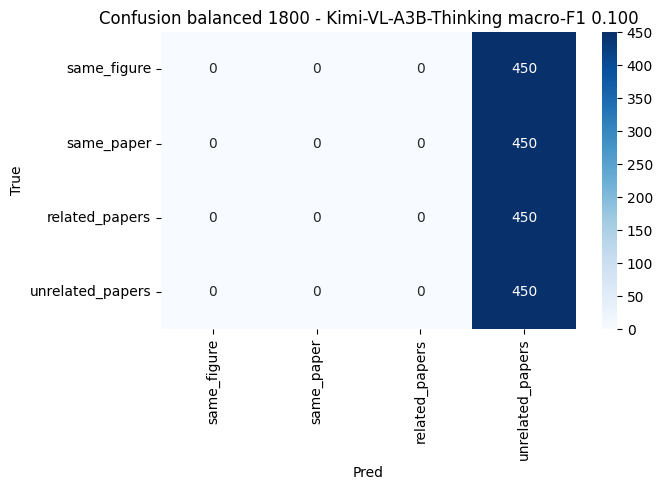

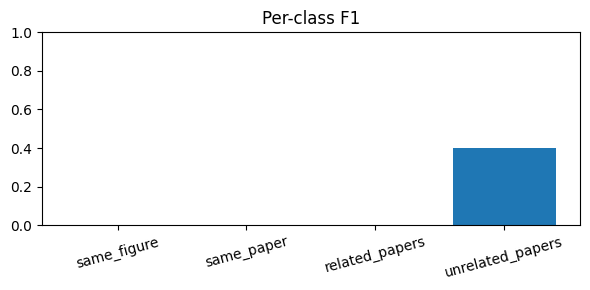

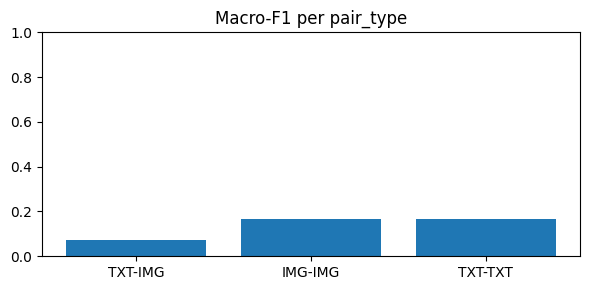

Saved plots


In [11]:
# --- 10. Visualization ---
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_cols, yticklabels=label_cols)
plt.title(f"Confusion balanced 1800 - {MODEL_ID.split('/')[-1]} macro-F1 {macro_f1:.3f}")
plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.savefig("confusion.png", dpi=150); plt.show()

plt.figure(figsize=(6, 3))
plt.bar(label_cols, per_class)
plt.title("Per-class F1"); plt.ylim(0, 1); plt.xticks(rotation=15); plt.tight_layout(); plt.savefig("per_class_f1.png"); plt.show()

pts, f1s = [], []
for pt in ["TXT-IMG", "IMG-IMG", "TXT-TXT"]:
    mask = train_bal["pair_type"] == pt
    if mask.sum() > 0 and len(y_true) >= mask.sum():
        f1s.append(f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0))
        pts.append(pt)
plt.figure(figsize=(6, 3))
plt.bar(pts, f1s)
plt.title("Macro-F1 per pair_type"); plt.ylim(0, 1); plt.tight_layout(); plt.savefig("per_pair_f1.png"); plt.show()
print("Saved plots")

In [12]:
# --- 11. Summary ---
elapsed = (time.time() - start_time) / 3600
print(f"\n{'='*60}")
print(f"Model: {MODEL_ID}  Thinking: {ENABLE_THINKING}")
print(f"Time: {elapsed:.2f}h  Samples: {len(preds_train)}/{len(train_bal)}")
print(f"Overall acc={acc:.4f} macro-F1={macro_f1:.4f}")
print(f"{'='*60}")
print("Outputs: preds_train.npy, preds_train_bal_final.npy, raw_outputs.jsonl, raw_outputs_final.jsonl")
print("         metrics.json, confusion.png, per_class_f1.png, per_pair_f1.png")


Model: moonshotai/Kimi-VL-A3B-Thinking  Thinking: True
Time: 4.20h  Samples: 1800/1800
Overall acc=0.2500 macro-F1=0.1000
Outputs: preds_train.npy, preds_train_bal_final.npy, raw_outputs.jsonl, raw_outputs_final.jsonl
         metrics.json, confusion.png, per_class_f1.png, per_pair_f1.png
